### Visualizing the phaseflip code

In [1]:
include("functions.jl")
using Plots, JLD2, LaTeXStrings, FileIO

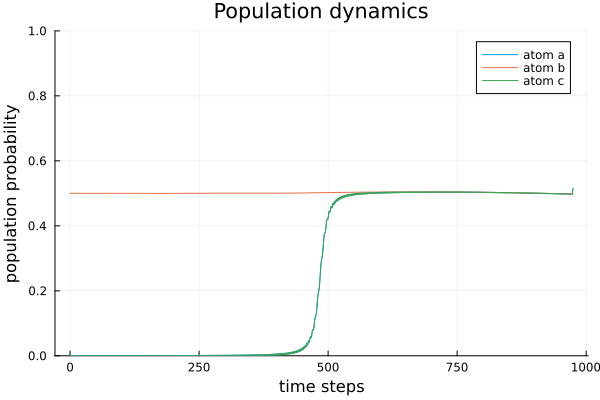

In [2]:
@load "/Users/akashmalemath/Documents/master_work/rydberg_qec/codework/phaseflip_code/results_data/N_atoms=5_γ_decay=0.0_Ntraj=1.jld2"

population_data = population_data;
# corrected_population_data = corrected_population_data;
# fidelity_data = fidelity_data;


plot(tspan, population_data[:a],  ylim=[0,1], label="atom a", xlabel="time steps", ylabel="population probability", title="Population dynamics")
plot!(tspan,population_data[:b], label="atom b")
plot!(tspan, population_data[:c], label="atom c")
# plot!(population_data[:a1],label="ancilla 1")
# plot!(population_data[:a2], label="ancilla 2")

In [3]:
length(population_data[:a])

9748

### Debugging phaseflip code

In [1]:
using QuantumOptics
using DifferentialEquations
using SparseArrays
using Plots

In [2]:
struct qubit_parameters
    Ω::Float64
    γ_Decay::Float64
    γ_dephase::Float64
    V_nn::Float64
    δ1::Float64
    δ2::Float64
end

function full_operator(gate, total_qubits, sites)
    """
    Applies an arbitrary gate on a specified site `i` in a `total_qubits`-qubit system.
    All other sites are identity operators.

    Args:
    - gate: AbstractOperator (arbitrary gate to apply on site `i`)
    - i: Array (site index to apply the gate, 1-based)
    - total_qubits: Int (total number of qubits)

    Returns:
    - operator: AbstractOperator (the full operator acting on the entire system)
    """
    # Ensure the gate is an AbstractOperator
    if !(gate isa AbstractOperator)
        throw(ArgumentError("The gate must be an AbstractOperator"))
    end

    # Create an identity operator for each qubit
    identity = transition(NLevelBasis(2), 1,1) + transition(NLevelBasis(2), 2,2)
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    identity_ops = [identity for _ in 1:total_qubits]
    
    # Replace the identity operator at site `i` with the provided gate
    for j in sites
        identity_ops[j] = gate
    end

    # Return the Kronecker product of all operators
    return tensor(reverse(identity_ops)...)
end


function get_qubit_parameters(p::qubit_parameters,t::Float64,mode::Symbol)
    """
    Function to get the parameters of the system at time t for the qubits
   
    Modes:
        - `:T1` → 0<=t<=T1: Pulse for the qubits A-B-C
        - `:T2` → 0<=t<=T2: Pulse for the ancillas 1-2
        - `:T3` → 0<=t<=T3: Pulse for the qubits A or C
        - `:T4` → 0<=t<=T3: Pulse for the qubit B

    Parameters: 
        - p:: qubit_parameters → Struct containing the qubit parameters
        - time t:: Float64
        - mode:: Symbol → Selects phase (`:T1` or `:T2` or `:T3` or `:T4`)

    Returns: 
        - parameters at time t:: Tuple
    """

    @assert mode in [:T1, :T2, :T3, :T4a, :T4b, :T5] "Invalid mode selected"

    #### Qubit Encoding Modes
    if mode == :T1
        Δt = Δ1_0 - p.δ1 * t
        return [p.Ω/2, p.Ω/2, Δt, Δt, p.V_nn, p.V_nn]

    #### Hadamard Mode 1    
    elseif mode == :T2
        return [p.Ω/2, p.Ω/2, p.Ω/2]
    
    #### Ancilla driving mode
    elseif mode == :T3
        Δt = Δ2_0 - p.δ2 * t
        return [p.Ω/2, p.Ω/2, Δt, Δt, p.V_nn/(2^6), p.V_nn/(2^6), p.V_nn/(2^6), p.V_nn/(2^6)]
    
    #### Correction mode for Atom A or C   
    elseif mode == :T4a
        Δt = Δac_0 - p.δ2 * t
        return [p.Ω/2, Δt, p.V_nn, p.V_nn/(2^6)]

    #### Correction mode for Atom B
    elseif mode == :T4b
        Δt = Δb_0 - p.δ2 * t
        return [p.Ω/2, Δt, p.V_nn, p.V_nn, p.V_nn/(2^6), p.V_nn/(2^6)]

    #### Hadamard Mode 2
    elseif mode == :T5
        return [p.Ω/2, p.Ω/2, p.Ω/2]

    end

end

get_qubit_parameters (generic function with 1 method)

In [3]:
total_qubits = 5
T1 = 970.0
T2_y = pi/2;
T2_z = pi;
basi = NLevelBasis(2)
p = qubit_parameters(1.0, 0.0, 0.0, -1000.0, 0.066, 0.108)
const Δ1_0 = 1032.0


const tspan1 = [0.0:0.1:T1;]

# System Hamiltonian 1 - driving atoms A-C
σx = transition(basi,1,2) + transition(basi,2,1)
σx_a = full_operator(σx, total_qubits, [1])
σx_b = full_operator(σx, total_qubits, [2])
σx_c = full_operator(σx, total_qubits, [3])

n = transition(basi,2,2)
n_b = full_operator(n, total_qubits, [2])
const n_a = full_operator(n, total_qubits, [1])
const n_c = full_operator(n, total_qubits, [3])
const nn_ab = full_operator(n, total_qubits, [1,2])
const nn_bc = full_operator(n, total_qubits, [2,3])
const coeff1 = [t->get_qubit_parameters(p,t,:T1)]
const H1 = LazySum([coeff1[1](tspan1[1])[i] for i ∈ 1:6],[σx_a, σx_c, n_a, n_c, nn_ab, nn_bc])


const tspan2_y = [0.0:0.1:T2_y;]  #Time span for applying hadamards on atoms A-B-C
const tspan2_z = [0.0:0.1:T2_z;]  #Time span for applying hadamards on atoms A-B-C
σy = -im * transition(basi,1,2) + im * transition(basi,2,1)
σy_a = full_operator(σy, total_qubits, [1])
σy_b = full_operator(σy, total_qubits, [2])
σy_c = full_operator(σy, total_qubits, [3])

σz = transition(basi,1,1) - transition(basi,2,2)
σz_a = full_operator(σz, total_qubits, [1])
σz_b = full_operator(σz, total_qubits, [2])
σz_c = full_operator(σz, total_qubits, [3])

const coeff2 = [t->get_qubit_parameters(p,t,:T2)]
const H2_y = LazySum([coeff2[1](tspan2_y[1])[i] for i ∈ 1:3],[σy_a, σy_b, σy_c])
const H2_z = LazySum([coeff2[1](tspan2_z[1])[i] for i ∈ 1:3],[σz_a, σz_b, σz_c])

LazySum(dim=32x32)
  basis: [NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2) ⊗ NLevel(N=2)]
  operators: 3

In [4]:
function Ht1(t)
    """
    Function to calculate the time dependent Hamiltonian for the MCWF method till time steps T1+T2.
        -- H1: Hamiltonian for driving atoms A-B-C for time 0:T1
        -- H2: Hamiltonian for applying hadamards on atoms A-B-C for time T1:T2
        -- H3: Hamiltonian for driving atoms 1-2 for time T2:T3
    
    Args:
        t:: Float64: Time
    
    Returns:
        H:: LazySum: Time dependent Hamiltonian
    """

    t<T1 || t==T1
    coeffs = coeff1[1](t)
    for i in eachindex(coeffs)
        H1.factors[i] = coeffs[i]
    end
    return H1

end

function Ht2(t)

    if t<(T2_z) || t==(T2_z)
        coeffs = coeff2[1](t)
        for i in eachindex(coeffs)
            H2_z.factors[i] = coeffs[i]
        end
        return H2_z

    elseif t<(T2_y+T2_z) || t==(T2_y+T2_z)
        coeffs = coeff2[1](t)
        for i in eachindex(coeffs)
            H2_y.factors[i] = coeffs[i]
        end
        return H2_y

    # elseif t<(T1+T2+T3) || t==(T1+T2+T3)
    #     coeffs = coeff3[1](t-(T1+T2))
    #     for i in eachindex(coeffs)
    #         H3.factors[i] = coeffs[i]
    #     end
        # return H3
    end 

end


function lindbaldian_dephase(γ_dephase::Float64,site::Array)
    """
    Function to calculate the Lindbaldian dephase operator for the MCWF method.
    The dephase operators are returned according to given respective sites.

    Args:
        γ_dephase:: Float64: Dephase rate
        site:: Array: Array of sites at which the decay operator acts

    Returns:
        C:: Array{Matrix}: Array of dephase operators acting on the system
    """
    basis = NLevelBasis(2)
    σ_z= transition(basis,1,1) - transition(basis,2,2)
    σ_z = Operator(σ_z.basis_l, σ_z.basis_r, SparseMatrixCSC{ComplexF32, Int64}(σ_z.data))

    identity = transition(basis,1,1) + transition(basis,2,2)
    identity = Operator(identity.basis_l, identity.basis_r, SparseMatrixCSC{ComplexF32, Int64}(identity.data))
    C = Vector{Operator}(undef, total_qubits)
    
    for i in 1:total_qubits
        if i in site
            C[i] = sqrt(γ_dephase) .* full_operator(σ_z, total_qubits, [i])
        else
            C[i] = full_operator(identity, total_qubits, [i])
        end
    end

    return C
end

const C = lindbaldian_dephase(0.0,[1,2,3,4,5])    
const Cdagger = [adjoint(c) for c in C]

function f1(t,ψ)
"""
Function to calculate the time evolution of the system using the MCWF method.

Args:
    t:: Float64: Time

Returns:
    H:: LazySum: Time dependent Hamiltonian
    C:: Array{Operator}: Array of decay operators acting on the system
    Cdagger:: Array{Operator}: Array of adjoint decay operators acting on the system
"""

    H = Ht1(t)

    return H, C, Cdagger
end

function f2(t,ψ)
"""
Function to calculate the time evolution of the system using the MCWF method.
Args:
    t:: Float64: Time
Returns:
    H:: LazySum: Time dependent Hamiltonian
    C:: Array{Operator}: Array of decay operators acting on the system
    Cdagger:: Array{Operator}: Array of adjoint decay operators acting on the system
"""

    H = Ht2(t)

    return H, C, Cdagger
end

f2 (generic function with 1 method)

In [5]:
# tspan = [0.0:0.1:(T1);]  #Time span for applying hadamards on atoms A-B-C

g = [1.0,0.0]
r = [0.0,1.0]
α = 1/sqrt(2)
β = 1/sqrt(2)


site_states = [g for _ in 1:total_qubits]
site_states[2] = α.*g + β.*r

ψ0 = reduce(kron, site_states)

full_basis = CompositeBasis([NLevelBasis(2) for _ in 1:total_qubits]...)
ψ0_ket = Ket(full_basis, ComplexF32.(ψ0));

In [7]:
tout, ψt, jumps = timeevolution.mcwf_dynamic(tspan1,ψ0_ket,f1, maxiters=1e9, seed=(1), display_jumps=true);

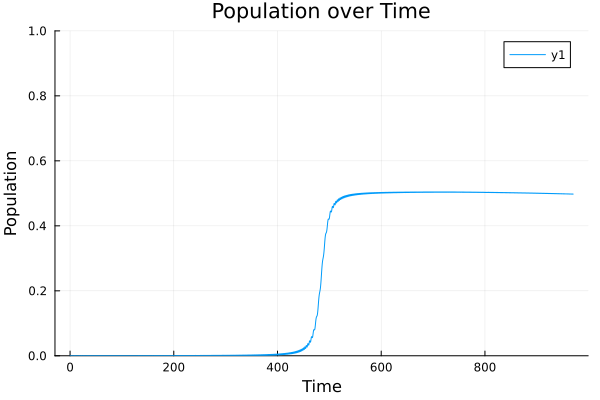

In [8]:
pop = zeros(length(tspan1))
pop .+= real(expect(n_c, ψt))

plot(tspan1, pop, ylim=[0, 1], title="Population over Time", xlabel="Time", ylabel="Population")

In [9]:
ψt_end = ψt[end].data/norm(ψt[end].data)
real(ψt_end * ψt_end')^2

32×32 Matrix{Float32}:
  0.461812     0.0  0.0  0.0  …  0.0  -0.45751      0.0  0.0  0.0
  0.0          0.0  0.0  0.0     0.0   0.0          0.0  0.0  0.0
  0.0          0.0  0.0  0.0     0.0   0.0          0.0  0.0  0.0
  0.0          0.0  0.0  0.0     0.0   0.0          0.0  0.0  0.0
 -0.000238222  0.0  0.0  0.0     0.0   0.000236     0.0  0.0  0.0
  0.0          0.0  0.0  0.0  …  0.0   0.0          0.0  0.0  0.0
  0.0          0.0  0.0  0.0     0.0   0.0          0.0  0.0  0.0
  0.0          0.0  0.0  0.0     0.0   0.0          0.0  0.0  0.0
 -0.000380313  0.0  0.0  0.0     0.0   0.000375141  0.0  0.0  0.0
  0.0          0.0  0.0  0.0     0.0   0.0          0.0  0.0  0.0
  ⋮                           ⋱                          ⋮    
  0.0          0.0  0.0  0.0     0.0   0.0          0.0  0.0  0.0
  0.0138634    0.0  0.0  0.0     0.0  -0.0137604    0.0  0.0  0.0
  0.0          0.0  0.0  0.0  …  0.0   0.0          0.0  0.0  0.0
  0.0          0.0  0.0  0.0     0.0   0.0          0.0 

In [14]:
a = [r,r,r,g,g]
b = [g,g,g,g,g]
ψ_ideal = α*reduce(kron,a)+ β*reduce(kron,b)
ψ_target = ψ_ideal / norm(ψ_ideal)

real(ψ_target * ψ_target')

32×32 Matrix{Float64}:
 0.5  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.5  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱  ⋮                        ⋮    
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     

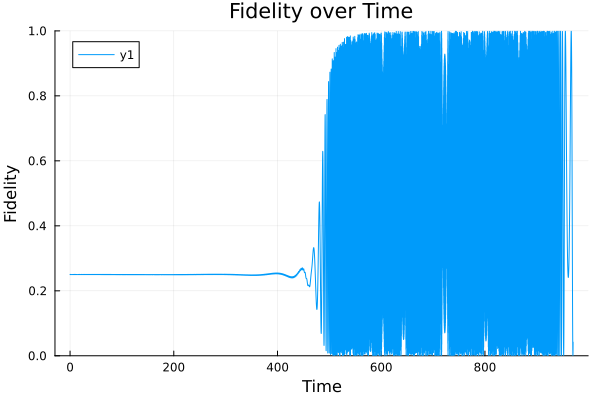

In [15]:
fidelities = []
for i in 1:length(ψt)
    ψt[i] = ψt[i] / norm(ψt[i]) 
    
    fidelity = abs(ψ_target' * ψt[i].data)^2
    push!(fidelities, fidelity)
end

plot(tspan1, fidelities, ylim=[0, 1], title="Fidelity over Time", xlabel="Time", ylabel="Fidelity")

In [13]:
ψ_superposition = α .* g + β .* r
ψ2_0 = reduce(kron, [ψ_superposition, ψ_superposition, g, g,g]);

ψ_target = ψ2_0;
ψ_target = ψ_target / norm(ψ_target);

ψ_end = ψt[end].data/norm(ψt[end].data)
fidelity = real(abs(ψ_target' * ψ_end)^2)
println("Fidelity: ", fidelity)

Fidelity: 0.1906309078522805


In [10]:
ψ_superposition = α .* g + β .* r
ψ2_0 = reduce(kron, [ψ_superposition, ψ_superposition, ψ_superposition, g,g]);

In [11]:
tspan2 = [0.0:0.1:(T2_y+T2_z);]  #Time span for applying hadamards on atoms A-B-C

full_basis = CompositeBasis([NLevelBasis(2) for _ in 1:total_qubits]...)
ψ2_0 = Ket(full_basis, ComplexF32.(ψ2_0));
tout, ψt, jumps = timeevolution.mcwf_dynamic(tspan2, ψ2_0, f2, maxiters=1e9, seed=(1), display_jumps=true);

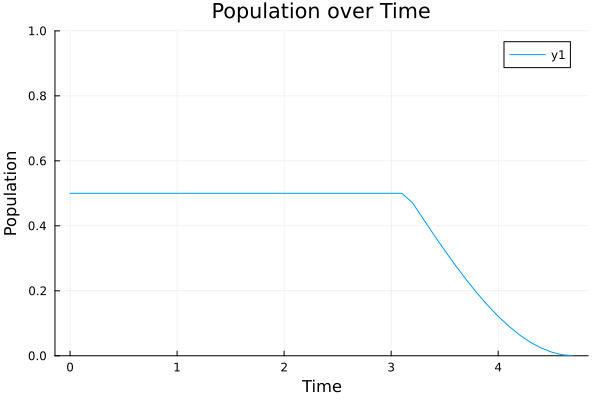

In [17]:
pop_h = zeros(length(tspan2))
pop_h .+= real(expect(n_c, ψt))
plot(tspan2, pop_h, ylim=[0, 1], title="Population over Time", xlabel="Time", ylabel="Population")